In [1]:
import wfdb
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Raw ECG Signal Exploration
Dataset: MIT-BIH Arrhythmia Database | Patient: 100 | Age: 69M
Sampling Rate: 360 Hz | Duration: ~30 minutes | Lead: MLII

In [2]:
# Streaming record 100 directly from PhysioNet - no manual download needed
record = wfdb.rdrecord('100', pn_dir='mitdb')

# Load the annotations (these mark where heartbeats occur)
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

print(record.__dict__)

{'record_name': '100', 'n_sig': 2, 'fs': 360, 'counter_freq': None, 'base_counter': None, 'sig_len': 650000, 'base_time': None, 'base_date': None, 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal'], 'sig_name': ['MLII', 'V5'], 'p_signal': array([[-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       ...,
       [-0.675, -0.365],
       [-0.765, -0.335],
       [-1.28 ,  0.   ]]), 'd_signal': None, 'e_p_signal': None, 'e_d_signal': None, 'file_name': ['100.dat', '100.dat'], 'fmt': ['212', '212'], 'samps_per_frame': [1, 1], 'skew': [None, None], 'byte_offset': [None, None], 'adc_gain': [200.0, 200.0], 'baseline': [1024, 1024], 'units': ['mV', 'mV'], 'adc_res': [11, 11], 'adc_zero': [1024, 1024], 'init_value': [995, 1011], 'checksum': [-22131, 20052], 'block_size': [0, 0]}


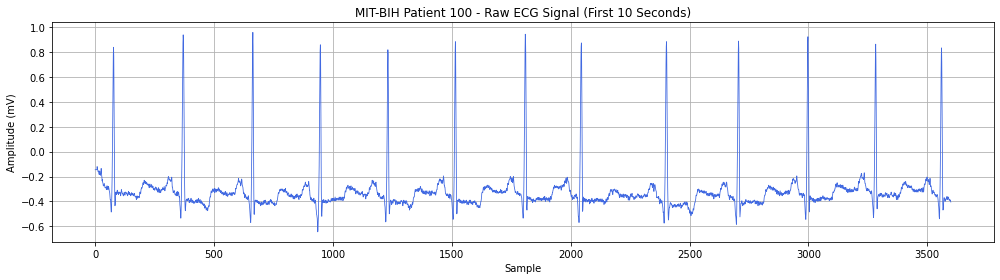

Sampling Rate: 360 Hz
Total samples: 650000
Signal duration: 30.09 minutes


In [3]:
# Extract the ECG signal - channel 0 is MLII (standard ECG lead)
ecg_signal = record.p_signal[:, 0]

# Sampling frequency - how many data points per second
fs = record.fs  

# Plot 10 seconds of the signal
plt.figure(figsize=(14, 4))
plt.plot(ecg_signal[:10*fs], color='royalblue', linewidth=0.8)
plt.title('MIT-BIH Patient 100 - Raw ECG Signal (First 10 Seconds)')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Sampling Rate: {fs} Hz")
print(f"Total samples: {len(ecg_signal)}")
print(f"Signal duration: {len(ecg_signal)/fs/60:.2f} minutes")